# Study 772 — Album-Drop — for the quants 🔬

The full battery: one-sample *t* per window, a random-window placebo, a leave-one-out jackknife, the costed net leg, and a seeded synthetic positive control. Everything offline once cached; fingerprint `5406b18c6109`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from album_drop import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching SPOT + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} drops resolved")


panel loaded; 27 of 27 drops resolved


## 1. One-sample *t* across independent album events

Each album drop is one independent event, so the unit is a one-sample *t* of the per-event abnormal return — **not** a daily panel (which would fake precision).

In [2]:
for label, col in [('2wk run-up','pre_s'),('1mo run-up','pre_l'),('2wk reaction','post_s'),('1mo reaction','post_l')]:
    s = st.one_sample_t(inc[col].values)
    print(f'{label:<14s} n={s["n"]}  mean={s["mean"]*100:+.3f}%  sd={s["sd"]*100:.2f}%  t={s["t"]:+.3f}')

2wk run-up     n=27  mean=+0.219%  sd=9.30%  t=+0.123
1mo run-up     n=27  mean=+1.436%  sd=12.40%  t=+0.602
2wk reaction   n=27  mean=-1.158%  sd=8.48%  t=-0.709
1mo reaction   n=27  mean=-1.622%  sd=9.08%  t=-0.928


## 2. Random-window placebo — is either move inside the luck cloud?

For each event we redraw a random, non-drop 2-week window on SPOT vs SPY and recompute the abnormal return; 20 seeds × 200 draws. If the observed mean sits in the tail of that null, it isn't ordinary tracking noise. (Spoiler: it is.)

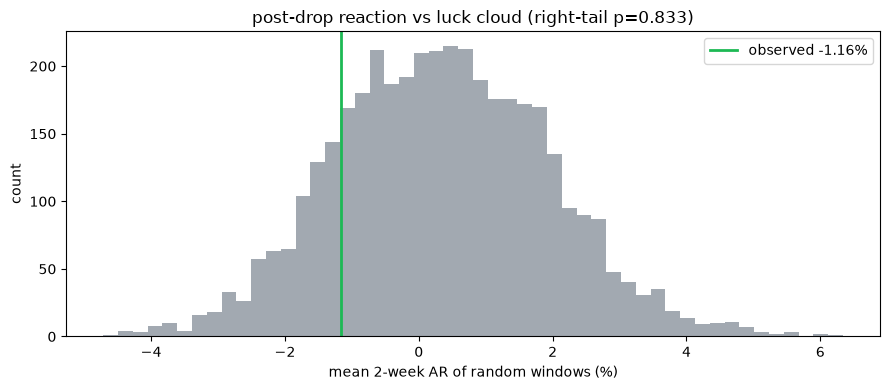

placebo: {'obs': -0.0116, 'placebo_mean': 0.0037, 'placebo_sd': 0.0156, 'p_value': 0.833, 'n_draws': 4000}


In [3]:
pl = st.placebo_pvalue(ev, prices, 'post_s', k=10, tail='right')
import numpy as np
spot, spy = prices[dt.INSTRUMENT], prices[dt.BENCHMARK]
common = spot.index.intersection(spy.index).sort_values()
rng = np.random.default_rng(999); draws = []
for _ in range(4000):
    vals = []
    for _e in range(int(inc.shape[0])):
        p = int(rng.integers(0, len(common)-11))
        vals.append(float(spot.loc[common[p+10]]/spot.loc[common[p]] - spy.loc[common[p+10]]/spy.loc[common[p]]))
    draws.append(np.mean(vals))
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(np.array(draws)*100, bins=50, color='#8b949e', alpha=0.8)
ax.axvline(pl['obs']*100, color='#1db954', lw=2, label=f"observed {pl['obs']*100:+.2f}%")
ax.set_xlabel('mean 2-week AR of random windows (%)'); ax.set_ylabel('count')
ax.set_title(f"post-drop reaction vs luck cloud (right-tail p={pl['p_value']:.3f})"); ax.legend()
plt.tight_layout(); plt.show()
print('placebo:', {k: round(v,4) if isinstance(v,float) else v for k,v in pl.items()})

## 3. Jackknife — is the tiny negative one bad album, or broad?

In [4]:
x = inc['post_s'].values
jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
print(f'full-sample t = {st.one_sample_t(x)["t"]:+.3f}')
print(f'jackknife t range [{min(jk):+.3f}, {max(jk):+.3f}] over {len(x)} leave-one-out draws')

full-sample t = -0.709
jackknife t range [-1.178, -0.275] over 27 leave-one-out draws


## 4. Tradability — net of costs

Calendar-known entry, so the signal window and the tradable window are the same (gross vs net). The run-up is a rounding error that costs erase; the reaction is a sub-1-*t* negative. No edge in any cut.

In [5]:
ev10 = st.build_event_table(prices, cost_bps=10.0); inc10 = ev10[ev10['included']]
for base, label in [('pre_s','2wk run-up'),('post_s','2wk reaction')]:
    g = st.one_sample_t(inc[base].values); n5 = st.one_sample_t(inc[base+'_net'].values); n10 = st.one_sample_t(inc10[base+'_net'].values)
    print(f'{label:<14s} gross {g["mean"]*100:+.3f}% (t={g["t"]:+.2f})  net@5 {n5["mean"]*100:+.3f}% (t={n5["t"]:+.2f})  net@10 {n10["mean"]*100:+.3f}% (t={n10["t"]:+.2f})')

2wk run-up     gross +0.219% (t=+0.12)  net@5 +0.119% (t=+0.07)  net@10 +0.019% (t=+0.01)
2wk reaction   gross -1.158% (t=-0.71)  net@5 -1.258% (t=-0.77)  net@10 -1.358% (t=-0.83)


## 5. Synthetic positive control — the detector works, the effect is just absent

The one-sample-*t* detector must stay quiet on a planted-null world and recover a planted pre-drop bump. It does both — so the flat real result is a true null, not a broken test.

null: mean t=+0.11 sd=1.21  |t|>=2 in 2/20 seeds
planted +1%: mean AR +2.017%  t=+2.16
planted +2%: mean AR +3.017%  t=+3.23


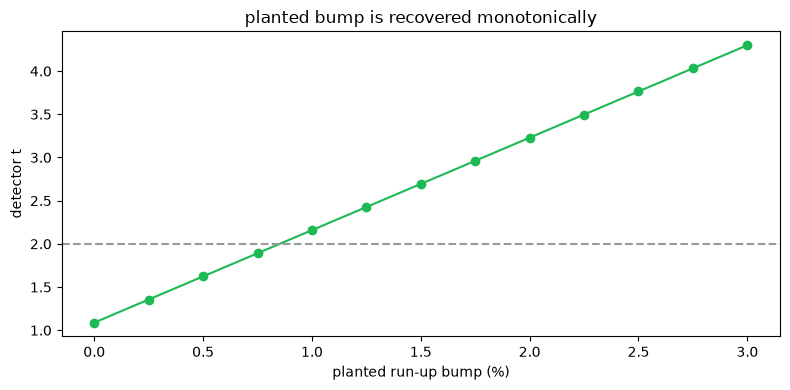

In [6]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=776+s, k=10)['t'] for s in range(20)])
print(f'null: mean t={null_ts.mean():+.2f} sd={null_ts.std(ddof=1):.2f}  |t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
for b in (0.01, 0.02):
    r = st.synthetic_detect(bump=b, seed=776, k=10)
    print(f'planted +{b*100:.0f}%: mean AR {r["mean"]*100:+.3f}%  t={r["t"]:+.2f}')
bumps = np.linspace(0, 0.03, 13)
ts = [st.synthetic_detect(bump=b, seed=776, k=10)['t'] for b in bumps]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(bumps*100, ts, 'o-', color='#1db954')
ax.axhline(2, color='0.6', ls='--'); ax.set_xlabel('planted run-up bump (%)'); ax.set_ylabel('detector t')
ax.set_title('planted bump is recovered monotonically'); plt.tight_layout(); plt.show()

## Verdict

**Signal: None.** Every real cut is indistinguishable from noise (run-up +0.22% *t* +0.12 / +1.44% *t* +0.60; reaction −1.16% *t* −0.71 / −1.62% *t* −0.93), placebo p = 0.53 / 0.83 dead-centre, jackknife never near significance — while the synthetic control cleanly recovers a planted +1%/+2% bump. **Tradability: Mirage.** No edge in any window, gross or net; a record streaming week is a rounding error against Spotify's subscription base.